# 🌆 Notebook 05 · Expansión Urbana y Zonas de Transición
---
**Proyecto:** Bogotá — Análisis Predictivo del Mercado Inmobiliario Urbano  
**Fuente:** UAECD / IDECA · SDP · 2020–2026  
**Autor:** Kevin Palacio Martinez

---
## 🎯 Objetivo

Identificar las zonas de frontera urbano-rural con mayor presión de
expansión, caracterizar los frentes de desarrollo activos y proyectar
el crecimiento urbano de Bogotá hacia 2030 mediante clustering espacial
y modelo de autómata celular.

## 📋 Contenido

| Sección | Descripción |
|---|---|
| 1 | Carga y preparación de capas territoriales |
| 2 | Caracterización de la frontera urbano-rural |
| 3 | Cruce con tratamientos urbanísticos POT |
| 4 | Clustering espacial — frentes de expansión activos |
| 5 | Modelo de autómata celular — proyección 2030 |
| 6 | Exportación y visualización de resultados |

---
## ⚙️ Sección 1 · Carga y preparación de capas territoriales

> Se integran las capas de valor catastral, clasificación de suelo,
> tratamientos urbanísticos POT y microterritorios rurales para
> construir el dataset de análisis de expansión urbana.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings('ignore')

from sqlalchemy import create_engine
from db_config import DB_URL
from sklearn.preprocessing import StandardScaler

pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style="whitegrid", font_scale=1.1)

engine = create_engine(DB_URL)
print("✓ Librerías cargadas")

✓ Librerías cargadas


In [2]:
# Manzanas con clasificación territorial — todos los años
query_manzanas = """
    SELECT
        vm.id, vm.cod_manzana, vm.localidad, vm.sector,
        vm.tipo_territorio, vm.anio,
        vm.valor_final, vm.estrato,
        vm.dist_tm_m, vm.dist_metro_m,
        ST_X(ST_Transform(ST_Centroid(vm.geom), 3116)) as x_m,
        ST_Y(ST_Transform(ST_Centroid(vm.geom), 3116)) as y_m,
        geom
    FROM catastro.valor_manzana vm
    WHERE vm.valor_final > 0
    ORDER BY vm.anio, vm.cod_manzana
"""
gdf = gpd.read_postgis(query_manzanas, engine, geom_col='geom')

# Tratamientos urbanísticos POT
query_pot = """
    SELECT codigo_tratamiento, nombre_tratamiento,
           tipologia, altura_max, geom
    FROM catastro.tratamiento_urbanistico
"""
gdf_pot = gpd.read_postgis(query_pot, engine, geom_col='geom')

# Clasificación de suelo por manzana
query_suelo = """
    SELECT cod_manzana, uso_economico, geom
    FROM catastro.clasificacion_suelo
"""
gdf_suelo = gpd.read_postgis(query_suelo, engine, geom_col='geom')

# Microterritorios rurales
query_rural = """
    SELECT id_microte, nombre_mic, area_micro, geom
    FROM catastro.microterritorios_rurales
"""
gdf_rural = gpd.read_postgis(query_rural, engine, geom_col='geom')

print(f"✓ Manzanas cargadas          : {len(gdf):,}")
print(f"✓ Polígonos POT              : {len(gdf_pot):,}")
print(f"✓ Manzanas clasificación     : {len(gdf_suelo):,}")
print(f"✓ Microterritorios rurales   : {len(gdf_rural):,}")

# Dataset de trabajo — 2026 para análisis actual
gdf_2026 = gdf[gdf['anio'] == 2026].copy()
print(f"\n✓ Manzanas 2026              : {len(gdf_2026):,}")

✓ Manzanas cargadas          : 298,010
✓ Polígonos POT              : 5,705
✓ Manzanas clasificación     : 43,714
✓ Microterritorios rurales   : 77

✓ Manzanas 2026              : 41,858


---
## 🌿 Sección 2 · Caracterización de la frontera urbano-rural

> Se analiza la distribución espacial y el comportamiento del valor
> del suelo en las zonas de transición entre lo urbano y lo rural.  
> Las manzanas **periurbanas** son el foco principal — son las que
> tienen mayor probabilidad de incorporarse al tejido urbano.
>
> **Indicadores de presión expansiva:**
> - Valorización acumulada superior al promedio urbano
> - Reducción de la brecha de valor con manzanas urbanas vecinas
> - Cercanía a infraestructura de transporte
> - Tratamiento POT de tipo "Desarrollo"

── Estadísticas por tipo de territorio 2026 ─────────────


,tipo_territorio,manzanas,mediana,promedio,std,cv
0,periurbano,230,"697,477.50","834,650.74","960,508.04",115.10
1,rural,147,"125,050.00","130,449.67","148,881.44",114.10
2,urbano,41481,"2,600,000.00","2,644,244.83","1,594,685.06",60.30



── Evolución brecha urbano/periurbano ───────────────────


tipo_territorio,anio,periurbano,rural,urbano,brecha_pct,tasa_convergencia
0,2020,"370,000.00","106,000.00","1,700,000.00",359.50,NaN
1,2021,"550,000.00","138,400.00","1,900,000.00",245.50,-114.00
2,2022,"440,000.00","138,400.00","1,900,000.00",331.80,86.30
3,2023,"325,835.50","49,400.00","2,100,000.00",544.50,212.70
4,2024,"475,000.00","49,400.00","2,160,000.00",354.70,-189.80
5,2025,"597,879.00","110,700.00","2,360,000.00",294.70,-60.00
6,2026,"697,477.50","125,050.00","2,600,000.00",272.80,-21.90


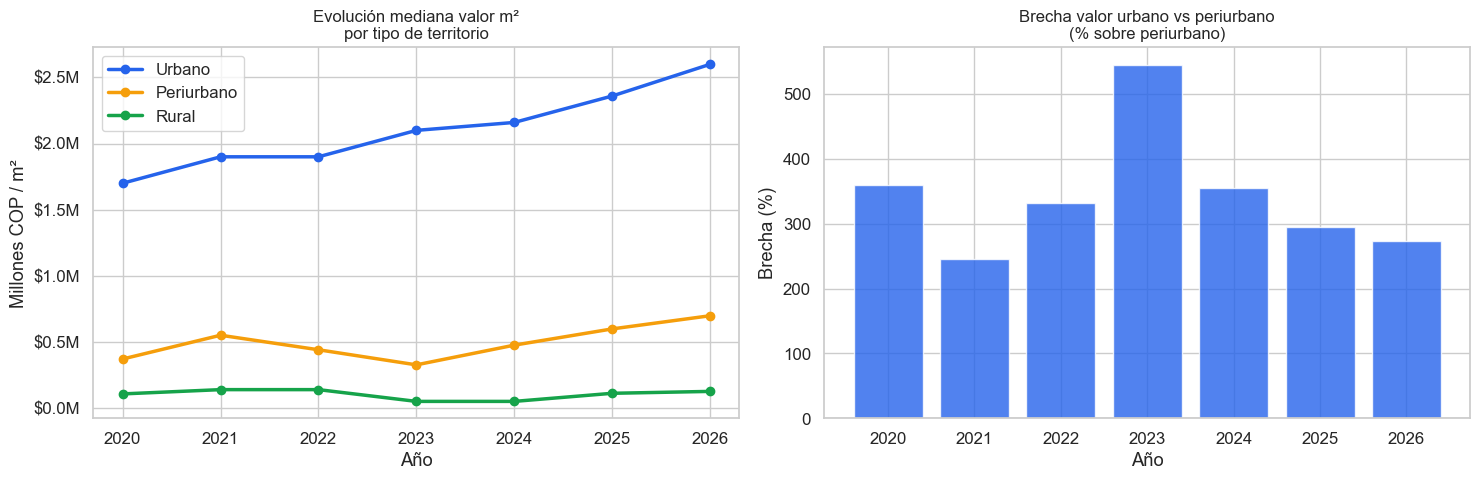

✓ Gráfico guardado en reports/figures/


In [3]:
# Estadísticas por tipo de territorio en 2026
stats_territorio = (
    gdf_2026[gdf_2026['valor_final'] > 0]
    .groupby('tipo_territorio')['valor_final']
    .agg(
        manzanas='count',
        mediana='median',
        promedio='mean',
        std='std'
    ).reset_index()
)
stats_territorio['cv'] = (
    stats_territorio['std'] / stats_territorio['promedio'] * 100
).round(1)

print("── Estadísticas por tipo de territorio 2026 ─────────────")
display(stats_territorio)

# Evolución de la brecha periurbano/urbano
serie = pd.read_parquet('../data/processed/serie_localidad.parquet')

brecha_evol = (
    gdf[gdf['valor_final'] > 0]
    .groupby(['tipo_territorio', 'anio'])['valor_final']
    .median()
    .reset_index()
    .pivot(index='anio', columns='tipo_territorio', values='valor_final')
    .reset_index()
)

if 'periurbano' in brecha_evol.columns and 'urbano' in brecha_evol.columns:
    brecha_evol['brecha_pct'] = (
        (brecha_evol['urbano'] - brecha_evol['periurbano']) /
        brecha_evol['periurbano'] * 100
    ).round(1)
    brecha_evol['tasa_convergencia'] = brecha_evol['brecha_pct'].diff().round(1)

print("\n── Evolución brecha urbano/periurbano ───────────────────")
display(brecha_evol)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Evolución de medianas
colores = {'urbano': '#2563EB', 'periurbano': '#F59E0B', 'rural': '#16A34A'}
for tipo in ['urbano', 'periurbano', 'rural']:
    if tipo in brecha_evol.columns:
        axes[0].plot(
            brecha_evol['anio'],
            brecha_evol[tipo] / 1_000_000,
            marker='o', linewidth=2.5,
            color=colores[tipo], label=tipo.capitalize()
        )
axes[0].set_title('Evolución mediana valor m²\npor tipo de territorio', fontsize=12)
axes[0].set_ylabel('Millones COP / m²')
axes[0].set_xlabel('Año')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
axes[0].legend()

# Brecha porcentual
axes[1].bar(brecha_evol['anio'], brecha_evol['brecha_pct'],
            color='#2563EB', alpha=0.8)
axes[1].set_title('Brecha valor urbano vs periurbano\n(% sobre periurbano)',
                  fontsize=12)
axes[1].set_ylabel('Brecha (%)')
axes[1].set_xlabel('Año')
axes[1].axhline(0, color='gray', linewidth=0.8)

plt.tight_layout()
plt.savefig('../reports/figures/20_frontera_urbano_rural.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado en reports/figures/")

---
## 🏗️ Sección 3 · Cruce con tratamientos urbanísticos POT

> Los **tratamientos urbanísticos** del POT de Bogotá definen
> qué puede hacerse en cada zona:
>
> | Tratamiento | Significado para expansión |
> |---|---|
> | 🟢 **Desarrollo** | Suelo sin urbanizar con licencia para hacerlo · expansión directa |
> | 🟡 **Renovación** | Zonas urbanas para transformación · densificación |
> | 🔵 **Consolidación** | Zonas consolidadas · crecimiento moderado |
> | 🟠 **Mejoramiento integral** | Zonas informales · urbanización progresiva |
> | 🟣 **Conservación** | Restricción de cambio · protección patrimonial |
>
> Las manzanas periurbanas con tratamiento **Desarrollo** son las
> candidatas más directas a incorporarse al tejido urbano.

✓ Manzanas con tratamiento POT : 41,357

── Manzanas por tratamiento y tipo de territorio ────────


tipo_territorio,periurbano,rural,urbano
nombre_tratamiento,,,
Conservación,1,0,816
Consolidación,36,0,20047
Desarrollo,32,0,692
Mejoramiento integral,104,34,11715
Renovación,11,0,7869



▸ Manzanas periurbanas con tratamiento Desarrollo: 32
▸ Por localidad:


,localidad,manzanas,valor_mediano
0,CHAPINERO,8,"1,900,000.00"
1,CIUDAD BOLIVAR,6,"150,832.50"
2,SAN CRISTOBAL,6,"127,500.00"
3,USAQUEN,5,"475,721.00"
4,USME,5,"243,500.00"
5,SUBA,2,"441,173.50"


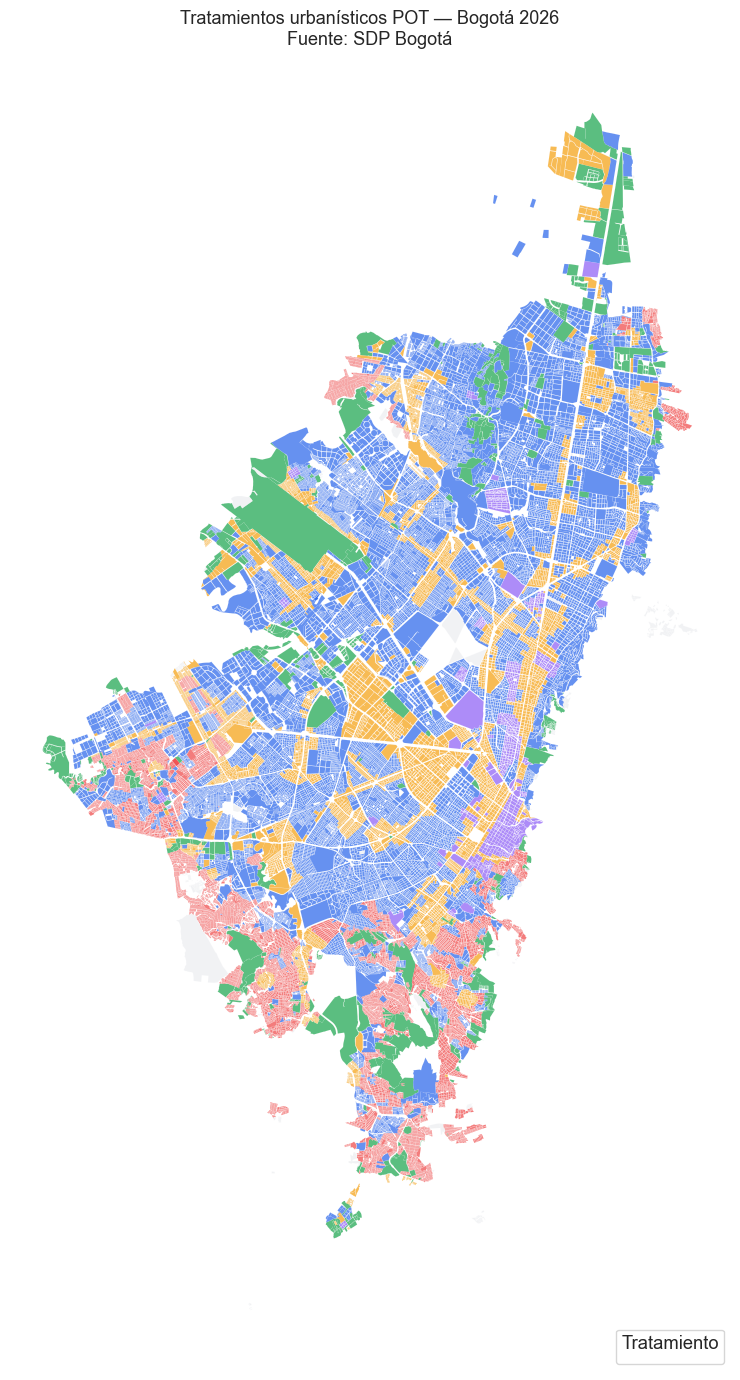

✓ Gráfico guardado en reports/figures/


In [4]:
# Asignar tratamiento POT a cada manzana por mayor área de intersección
query_pot_manzana = """
    SELECT DISTINCT ON (vm.id)
        vm.id,
        vm.cod_manzana,
        vm.tipo_territorio,
        vm.localidad,
        vm.valor_final,
        tu.nombre_tratamiento,
        tu.codigo_tratamiento,
        ST_Area(ST_Intersection(vm.geom, tu.geom)) /
        ST_Area(vm.geom) * 100 AS pct_interseccion
    FROM catastro.valor_manzana vm
    JOIN catastro.tratamiento_urbanistico tu
        ON ST_Intersects(vm.geom, tu.geom)
    WHERE vm.anio = 2026
      AND vm.valor_final > 0
    ORDER BY vm.id,
             ST_Area(ST_Intersection(vm.geom, tu.geom)) DESC
"""
df_pot_manzana = pd.read_sql(query_pot_manzana, engine)

print(f"✓ Manzanas con tratamiento POT : {len(df_pot_manzana):,}")

# Distribución por tipo de territorio y tratamiento
pivot_pot = (
    df_pot_manzana.groupby(['tipo_territorio', 'nombre_tratamiento'])
    .size()
    .reset_index(name='manzanas')
    .pivot(index='nombre_tratamiento',
           columns='tipo_territorio',
           values='manzanas')
    .fillna(0)
    .astype(int)
)

print("\n── Manzanas por tratamiento y tipo de territorio ────────")
display(pivot_pot)

# Manzanas periurbanas con tratamiento Desarrollo — frentes directos
periurbano_desarrollo = df_pot_manzana[
    (df_pot_manzana['tipo_territorio'] == 'periurbano') &
    (df_pot_manzana['nombre_tratamiento'] == 'Desarrollo')
]
print(f"\n▸ Manzanas periurbanas con tratamiento Desarrollo: "
      f"{len(periurbano_desarrollo):,}")
print(f"▸ Por localidad:")
display(
    periurbano_desarrollo.groupby('localidad')
    .agg(manzanas=('id','count'),
         valor_mediano=('valor_final','median'))
    .sort_values('manzanas', ascending=False)
    .reset_index()
)

# Visualización
colores_pot = {
    'Desarrollo':           '#16A34A',
    'Renovación':           '#F59E0B',
    'Consolidación':        '#2563EB',
    'Mejoramiento integral':'#EF4444',
    'Conservación':         '#8B5CF6'
}

fig, ax = plt.subplots(figsize=(12, 14))
gdf_2026_plot = gdf_2026.merge(
    df_pot_manzana[['id','nombre_tratamiento']], on='id', how='left'
)

for tratamiento, color in colores_pot.items():
    subset = gdf_2026_plot[
        gdf_2026_plot['nombre_tratamiento'] == tratamiento
    ]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, linewidth=0.05,
                   alpha=0.7, label=f'{tratamiento} ({len(subset):,})')

# Sin tratamiento
sin_pot = gdf_2026_plot[gdf_2026_plot['nombre_tratamiento'].isna()]
sin_pot.plot(ax=ax, color='#E5E7EB', linewidth=0.05,
             alpha=0.5, label=f'Sin datos ({len(sin_pot):,})')

ax.set_title('Tratamientos urbanísticos POT — Bogotá 2026\n'
             'Fuente: SDP Bogotá', fontsize=13)
ax.set_axis_off()
ax.legend(title='Tratamiento', loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../reports/figures/21_tratamientos_pot.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado en reports/figures/")

---
## 🔴 Sección 4 · Clustering espacial — Frentes de expansión activos

> Se aplica **DBSCAN** (Density-Based Spatial Clustering) sobre
> las manzanas periurbanas para identificar frentes de expansión
> activos — zonas donde la presión de valorización y la proximidad
> al tejido urbano indican desarrollo inminente.
>
> Las variables de clustering combinan:
> - Ubicación geográfica (coordenadas en metros)
> - Presión de valorización acumulada 2020–2026
> - Distancia a infraestructura de transporte
> - Tratamiento POT asignado
>
> **Interpretación de clusters:**
> - **Cluster activo** — manzanas periurbanas con alta valorización
>   y proximidad a transporte · expansión probable en 2-5 años
> - **Cluster latente** — valorización moderada · expansión en 5-10 años
> - **Ruido** — manzanas aisladas sin patrón claro

✓ Manzanas periurbanas 2026 : 230
✓ Clusters identificados    : 15
✓ Manzanas en clusters      : 152
✓ Manzanas ruido            : 78

── Caracterización de clusters ──────────────────────────


,cluster,manzanas,valor_mediano,valorizacion_acumulada,dist_tm_promedio,localidades
5,5,13,"700,000.00",250.00,"3,222.64",SAN CRISTOBAL
7,7,5,"876,000.00",136.76,"3,951.00",CIUDAD BOLIVAR
11,11,10,"860,000.00",100.00,"3,589.02",CIUDAD BOLIVAR
8,8,8,"458,000.00",99.13,"5,361.89",USME
6,6,6,"460,160.50",81.26,"3,701.39","USME, SAN CRISTOBAL"
2,2,16,"162,228.50",79.92,"1,330.62",CHAPINERO
3,3,16,"130,825.00",79.92,"4,036.06",CHAPINERO
4,4,20,"860,000.00",79.92,"2,348.19","SANTA FE, SAN CRISTOBAL"
10,10,6,"352,136.50",79.92,"5,961.60",USME
1,1,10,"1,200,000.00",79.10,"2,394.28",USAQUEN


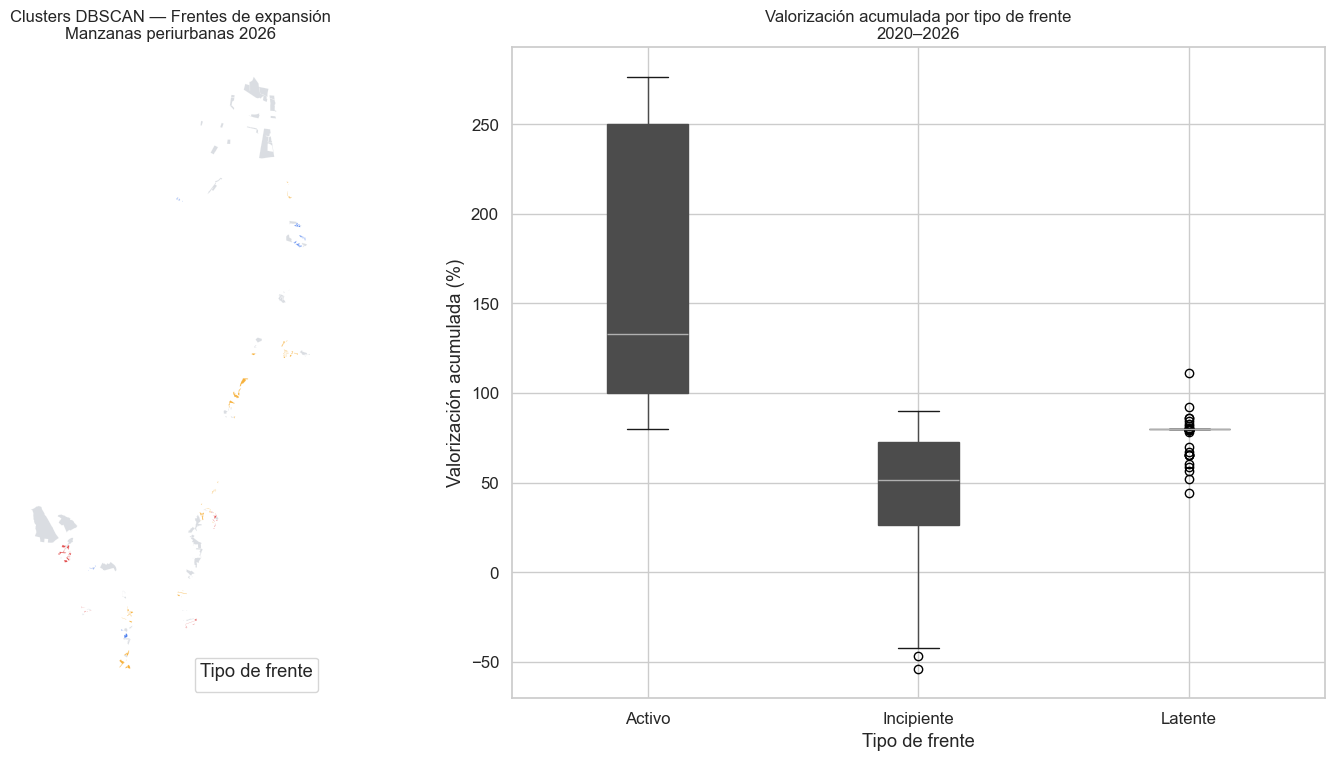

✓ Gráfico guardado en reports/figures/


In [5]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Dataset de manzanas periurbanas con valorización
query_periurbano = """
    SELECT
        vm.id, vm.cod_manzana, vm.localidad, vm.sector,
        vm.valor_final, vm.dist_tm_m, vm.dist_metro_m,
        vm.estrato,
        ST_X(ST_Transform(ST_Centroid(vm.geom), 3116)) as x_m,
        ST_Y(ST_Transform(ST_Centroid(vm.geom), 3116)) as y_m,
        vm.geom
    FROM catastro.valor_manzana vm
    WHERE vm.tipo_territorio = 'periurbano'
      AND vm.valor_final > 0
      AND vm.anio = 2026
"""
gdf_periurbano = gpd.read_postgis(query_periurbano, engine, geom_col='geom')

# Valorización acumulada por manzana
pivot = pd.read_parquet('../data/processed/valorizacion_manzana.parquet')
gdf_periurbano = gdf_periurbano.merge(
    pivot[['cod_manzana', 'valorizacion_acumulada']],
    on='cod_manzana', how='left'
)
gdf_periurbano['valorizacion_acumulada'] = (
    gdf_periurbano['valorizacion_acumulada'].fillna(
        gdf_periurbano['valorizacion_acumulada'].median()
    )
)

print(f"✓ Manzanas periurbanas 2026 : {len(gdf_periurbano):,}")

# Features para clustering
features_cluster = ['x_m', 'y_m', 'valorizacion_acumulada',
                    'dist_tm_m', 'dist_metro_m']
X_cluster = gdf_periurbano[features_cluster].fillna(0).values

scaler_cl = StandardScaler()
X_scaled  = scaler_cl.fit_transform(X_cluster)

# DBSCAN
dbscan = DBSCAN(eps=0.4, min_samples=5, n_jobs=-1)
gdf_periurbano['cluster'] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(gdf_periurbano['cluster'])) - \
             (1 if -1 in gdf_periurbano['cluster'].values else 0)
n_ruido    = (gdf_periurbano['cluster'] == -1).sum()

print(f"✓ Clusters identificados    : {n_clusters}")
print(f"✓ Manzanas en clusters      : {(gdf_periurbano['cluster'] != -1).sum():,}")
print(f"✓ Manzanas ruido            : {n_ruido:,}")

# Caracterización de clusters
stats_clusters = (
    gdf_periurbano[gdf_periurbano['cluster'] != -1]
    .groupby('cluster')
    .agg(
        manzanas=('id', 'count'),
        valor_mediano=('valor_final', 'median'),
        valorizacion_acumulada=('valorizacion_acumulada', 'median'),
        dist_tm_promedio=('dist_tm_m', 'mean'),
        localidades=('localidad', lambda x: ', '.join(x.unique()[:3]))
    )
    .reset_index()
    .sort_values('valorizacion_acumulada', ascending=False)
)

print("\n── Caracterización de clusters ──────────────────────────")
display(stats_clusters)

# Clasificar clusters por nivel de actividad
q75 = stats_clusters['valorizacion_acumulada'].quantile(0.75)
q25 = stats_clusters['valorizacion_acumulada'].quantile(0.25)

def clasificar_cluster(val):
    if val >= q75:
        return 'Activo'
    elif val >= q25:
        return 'Latente'
    else:
        return 'Incipiente'

stats_clusters['tipo_cluster'] = stats_clusters[
    'valorizacion_acumulada'
].apply(clasificar_cluster)

cluster_tipo_map = dict(
    zip(stats_clusters['cluster'], stats_clusters['tipo_cluster'])
)
gdf_periurbano['tipo_cluster'] = gdf_periurbano['cluster'].map(
    cluster_tipo_map
).fillna('Ruido')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

colores_cluster = {
    'Activo':     '#DC2626',
    'Latente':    '#F59E0B',
    'Incipiente': '#2563EB',
    'Ruido':      '#D1D5DB'
}

for tipo, color in colores_cluster.items():
    subset = gdf_periurbano[gdf_periurbano['tipo_cluster'] == tipo]
    if len(subset) > 0:
        subset.plot(ax=axes[0], color=color, linewidth=0.1,
                   alpha=0.8, label=f'{tipo} ({len(subset):,})')

axes[0].set_title('Clusters DBSCAN — Frentes de expansión\nManzanas periurbanas 2026',
                  fontsize=12)
axes[0].set_axis_off()
axes[0].legend(title='Tipo de frente', loc='lower right', fontsize=9)

# Distribución de valorización por tipo
gdf_periurbano[gdf_periurbano['tipo_cluster'] != 'Ruido'].boxplot(
    column='valorizacion_acumulada',
    by='tipo_cluster',
    ax=axes[1],
    patch_artist=True
)
axes[1].set_title('Valorización acumulada por tipo de frente\n2020–2026',
                  fontsize=12)
axes[1].set_xlabel('Tipo de frente')
axes[1].set_ylabel('Valorización acumulada (%)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../reports/figures/22_clusters_expansion.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado en reports/figures/")

---
## 🤖 Sección 5 · Modelo de autómata celular — Proyección 2030

> El **autómata celular** modela la expansión urbana como un proceso
> donde cada celda (manzana) puede cambiar de estado según el estado
> de sus vecinos y sus propias características.
>
> **Estados posibles:**
> - `0` — Rural · sin presión de desarrollo
> - `1` — Periurbano · en transición
> - `2` — Urbano consolidado
>
> **Reglas de transición calibradas con datos 2020–2026:**
> - Una manzana rural con ≥2 vecinos periurbanos o urbanos
>   y tratamiento POT de Desarrollo tiene alta probabilidad
>   de transitar a periurbano
> - Una manzana periurbana con ≥3 vecinos urbanos y valorización
>   acumulada >50% tiene alta probabilidad de transitar a urbano

> ⚠️ **Nota metodológica:** El autómata celular se implementa sobre
> una grilla regular derivada de los centroides de manzana.
> La resolución es aproximada — no reemplaza un modelo de simulación
> urbana completo pero es válido como herramienta de prospectiva.

In [6]:
from scipy.spatial import cKDTree

# Dataset completo con estado territorial por año
query_estados = """
    SELECT
        vm.cod_manzana,
        vm.anio,
        vm.tipo_territorio,
        vm.valor_final,
        ST_X(ST_Transform(ST_Centroid(vm.geom), 3116)) as x_m,
        ST_Y(ST_Transform(ST_Centroid(vm.geom), 3116)) as y_m
    FROM catastro.valor_manzana vm
    WHERE vm.valor_final > 0
    ORDER BY vm.cod_manzana, vm.anio
"""
df_estados = pd.read_sql(query_estados, engine)

# Codificar estados
estado_map = {'urbano': 2, 'periurbano': 1, 'rural': 0}
df_estados['estado'] = df_estados['tipo_territorio'].map(estado_map).fillna(0)

# Pivot por manzana y año
pivot_estados = df_estados.pivot_table(
    index='cod_manzana',
    columns='anio',
    values='estado',
    aggfunc='first'
).reset_index()

# Coordenadas 2026
coords_2026 = (
    df_estados[df_estados['anio'] == 2026]
    [['cod_manzana', 'x_m', 'y_m', 'valor_final']]
    .drop_duplicates('cod_manzana')
)
pivot_estados = pivot_estados.merge(coords_2026, on='cod_manzana', how='left')
pivot_estados = pivot_estados.dropna(subset=['x_m', 'y_m'])

print(f"✓ Manzanas con serie completa : {len(pivot_estados):,}")

# Construir árbol KD para vecinos
coords_array = pivot_estados[['x_m', 'y_m']].values
tree = cKDTree(coords_array)

# Función de transición
def calcular_transicion(estados_actuales, coords, tree,
                        valorizacion, pot_desarrollo, n_vecinos=8):
    nuevos_estados = estados_actuales.copy()
    distancias, indices = tree.query(coords, k=n_vecinos+1)

    for i in range(len(estados_actuales)):
        vecinos_idx  = indices[i][1:]
        estado_actual = estados_actuales[i]
        estados_vec  = estados_actuales[vecinos_idx]
        n_urbanos    = (estados_vec == 2).sum()
        n_periurbanos = (estados_vec == 1).sum()
        val_acum     = valorizacion[i] if not np.isnan(valorizacion[i]) else 0

        # Reglas de transición
        if estado_actual == 0:  # Rural → Periurbano
            prob = 0.0
            if n_periurbanos + n_urbanos >= 2:
                prob += 0.3
            if pot_desarrollo[i]:
                prob += 0.4
            if val_acum > 30:
                prob += 0.2
            if np.random.random() < prob:
                nuevos_estados[i] = 1

        elif estado_actual == 1:  # Periurbano → Urbano
            prob = 0.0
            if n_urbanos >= 3:
                prob += 0.4
            if val_acum > 50:
                prob += 0.3
            if pot_desarrollo[i]:
                prob += 0.2
            if np.random.random() < prob:
                nuevos_estados[i] = 2

    return nuevos_estados

# Preparar variables para la simulación
pivot_val = pd.read_parquet('../data/processed/valorizacion_manzana.parquet')
pivot_estados = pivot_estados.merge(
    pivot_val[['cod_manzana','valorizacion_acumulada']],
    on='cod_manzana', how='left'
)

# Flag de tratamiento Desarrollo
periurbano_desarrollo_set = set(periurbano_desarrollo['id'].values
                                 if 'id' in periurbano_desarrollo.columns
                                 else [])
pot_query = """
    SELECT DISTINCT vm.cod_manzana
    FROM catastro.valor_manzana vm
    JOIN catastro.tratamiento_urbanistico tu
        ON ST_Intersects(vm.geom, tu.geom)
    WHERE tu.nombre_tratamiento = 'Desarrollo'
      AND vm.anio = 2026
"""
manzanas_desarrollo = pd.read_sql(pot_query, engine)['cod_manzana'].values
pivot_estados['es_desarrollo'] = pivot_estados['cod_manzana'].isin(
    manzanas_desarrollo
)

# Estado inicial 2026
estado_actual = pivot_estados[2026].fillna(0).astype(int).values
valorizacion  = pivot_estados['valorizacion_acumulada'].fillna(0).values
es_desarrollo = pivot_estados['es_desarrollo'].values
coords_sim    = pivot_estados[['x_m', 'y_m']].values

# Simulación 2027–2030 (4 iteraciones = 4 años)
np.random.seed(42)
estados_por_anio = {2026: estado_actual.copy()}

for anio in range(2027, 2031):
    estado_actual = calcular_transicion(
        estado_actual, coords_sim, tree,
        valorizacion, es_desarrollo
    )
    estados_por_anio[anio] = estado_actual.copy()
    n_urbano   = (estado_actual == 2).sum()
    n_periurb  = (estado_actual == 1).sum()
    n_rural    = (estado_actual == 0).sum()
    print(f"  {anio} → Urbano: {n_urbano:,} · "
          f"Periurbano: {n_periurb:,} · Rural: {n_rural:,}")

# Identificar manzanas que transitan rural→periurbano o periurbano→urbano
pivot_estados['estado_2026'] = estados_por_anio[2026]
pivot_estados['estado_2030'] = estados_por_anio[2030]
pivot_estados['cambio'] = pivot_estados['estado_2030'] - \
                           pivot_estados['estado_2026']

nueva_expansion = pivot_estados[pivot_estados['cambio'] > 0]
print(f"\n✓ Manzanas con expansión proyectada 2026→2030 : "
      f"{len(nueva_expansion):,}")
print(f"  Rural → Periurbano : "
      f"{((pivot_estados['estado_2026']==0) & (pivot_estados['estado_2030']==1)).sum():,}")
print(f"  Periurbano → Urbano: "
      f"{((pivot_estados['estado_2026']==1) & (pivot_estados['estado_2030']==2)).sum():,}")

✓ Manzanas con serie completa : 41,823
  2027 → Urbano: 41,578 · Periurbano: 123 · Rural: 122
  2028 → Urbano: 41,623 · Periurbano: 99 · Rural: 101
  2029 → Urbano: 41,658 · Periurbano: 84 · Rural: 81
  2030 → Urbano: 41,681 · Periurbano: 73 · Rural: 69

✓ Manzanas con expansión proyectada 2026→2030 : 290
  Rural → Periurbano : 55
  Periurbano → Urbano: 212


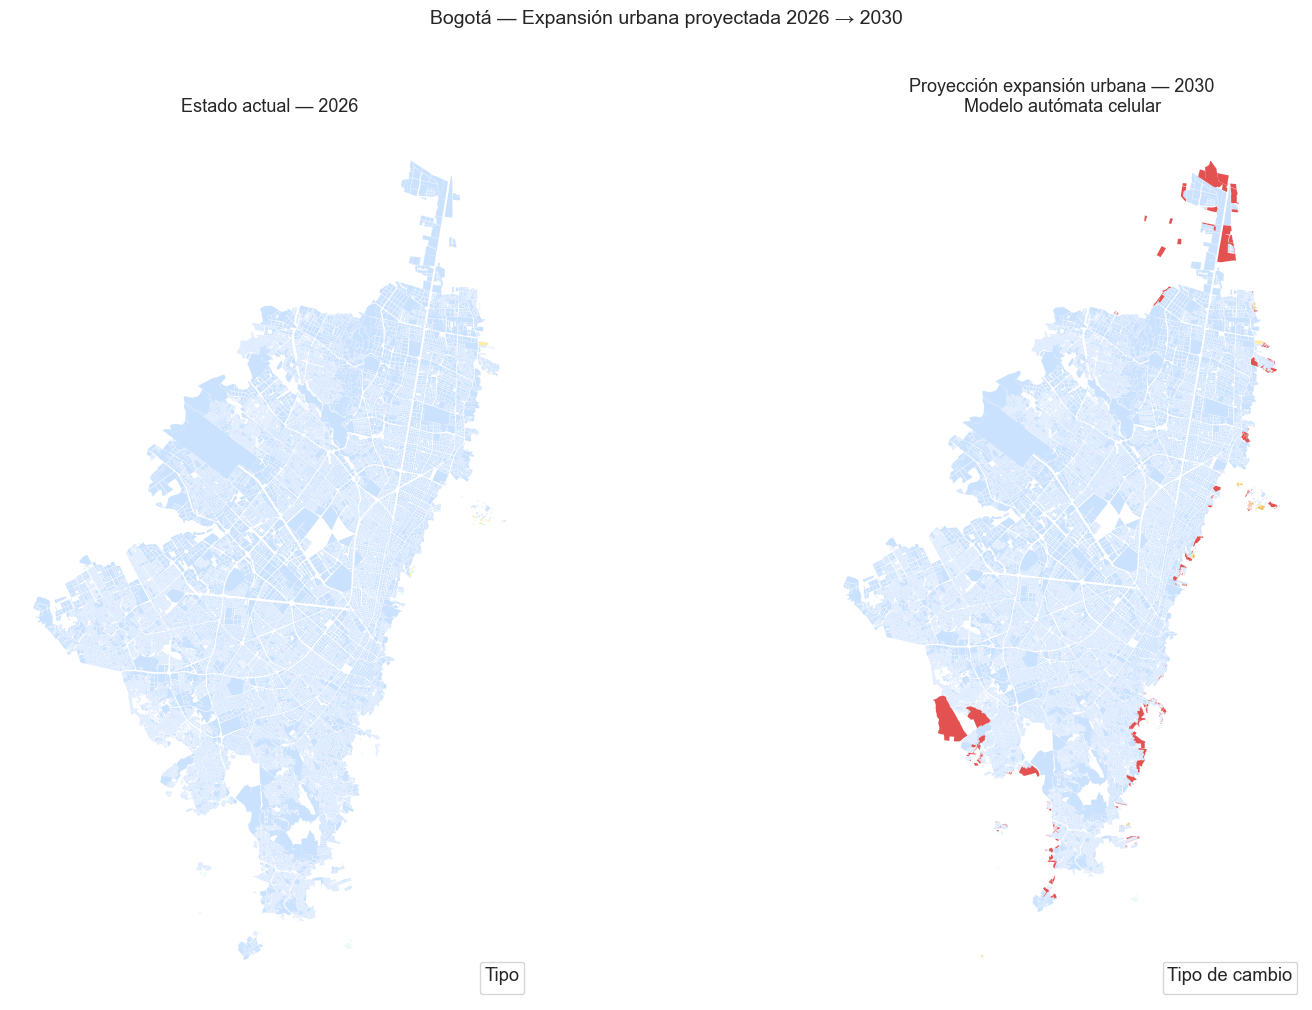

✓ Gráfico guardado en reports/figures/


In [7]:
# Merge resultados con geometría
gdf_automata = gdf_2026[['cod_manzana','geom']].drop_duplicates('cod_manzana')
gdf_automata = gdf_automata.merge(
    pivot_estados[['cod_manzana','estado_2026',
                   'estado_2030','cambio']],
    on='cod_manzana', how='left'
)
gdf_automata['estado_2030'] = gdf_automata['estado_2030'].fillna(
    gdf_automata['estado_2026']
)
gdf_automata['cambio'] = gdf_automata['cambio'].fillna(0)

# Clasificar tipo de cambio
def tipo_cambio(row):
    if row['cambio'] == 0 and row['estado_2030'] == 2:
        return 'Urbano estable'
    elif row['cambio'] == 0 and row['estado_2030'] == 1:
        return 'Periurbano estable'
    elif row['cambio'] == 0 and row['estado_2030'] == 0:
        return 'Rural estable'
    elif row['estado_2026'] == 1 and row['estado_2030'] == 2:
        return 'Periurbano → Urbano'
    elif row['estado_2026'] == 0 and row['estado_2030'] == 1:
        return 'Rural → Periurbano'
    return 'Sin cambio'

gdf_automata['tipo_cambio'] = gdf_automata.apply(tipo_cambio, axis=1)

colores_cambio = {
    'Urbano estable':       '#BFDBFE',
    'Periurbano estable':   '#FDE68A',
    'Rural estable':        '#D1FAE5',
    'Periurbano → Urbano':  '#DC2626',
    'Rural → Periurbano':   '#F59E0B',
    'Sin cambio':           '#E5E7EB'
}

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Mapa 2026
for tipo in ['Urbano estable', 'Periurbano estable', 'Rural estable']:
    subset = gdf_automata[gdf_automata['tipo_cambio'] == tipo]
    if len(subset) > 0:
        subset.plot(ax=axes[0], color=colores_cambio[tipo],
                   linewidth=0.05, alpha=0.8,
                   label=f'{tipo} ({len(subset):,})')
axes[0].set_title('Estado actual — 2026', fontsize=13)
axes[0].set_axis_off()
axes[0].legend(title='Tipo', loc='lower right', fontsize=8)

# Mapa 2030 con cambios
for tipo, color in colores_cambio.items():
    subset = gdf_automata[gdf_automata['tipo_cambio'] == tipo]
    if len(subset) > 0:
        subset.plot(ax=axes[1], color=color,
                   linewidth=0.05, alpha=0.8,
                   label=f'{tipo} ({len(subset):,})')
axes[1].set_title('Proyección expansión urbana — 2030\nModelo autómata celular',
                  fontsize=13)
axes[1].set_axis_off()
axes[1].legend(title='Tipo de cambio', loc='lower right', fontsize=8)

plt.suptitle('Bogotá — Expansión urbana proyectada 2026 → 2030',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/23_automata_celular_2030.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado en reports/figures/")

---
## 💾 Sección 6 · Exportación y visualización de resultados

> Se exportan los resultados a PostGIS para visualización en QGIS
> y se generan mapas HTML interactivos para el portafolio.

In [8]:
from sqlalchemy import text

# Exportar resultados del autómata a PostGIS
gdf_export = gdf_automata.copy()
gdf_export = gdf_export.set_geometry('geom')

gdf_export.to_postgis(
    name='proyeccion_expansion_2030',
    con=engine,
    schema='catastro',
    if_exists='replace',
    index=False
)

with engine.connect() as conn:
    conn.execute(text("""
        CREATE INDEX IF NOT EXISTS idx_proyeccion_expansion_geom
        ON catastro.proyeccion_expansion_2030 USING GIST (geom);
    """))
    conn.commit()

print("✓ Tabla catastro.proyeccion_expansion_2030 creada en PostgreSQL")

# Exportar clusters a PostGIS
gdf_periurbano_export = gdf_periurbano[
    ['cod_manzana', 'localidad', 'sector', 'cluster',
     'tipo_cluster', 'valor_final', 'valorizacion_acumulada',
     'dist_tm_m', 'geom']
].copy()

gdf_periurbano_export.to_postgis(
    name='clusters_expansion_periurbano',
    con=engine,
    schema='catastro',
    if_exists='replace',
    index=False
)

print("✓ Tabla catastro.clusters_expansion_periurbano creada en PostgreSQL")

# Resumen final
print("\n── Resumen de expansión proyectada 2026→2030 ────────────")
display(
    gdf_automata['tipo_cambio'].value_counts()
    .reset_index()
    .rename(columns={'tipo_cambio': 'tipo', 'count': 'manzanas'})
)

✓ Tabla catastro.proyeccion_expansion_2030 creada en PostgreSQL
✓ Tabla catastro.clusters_expansion_periurbano creada en PostgreSQL

── Resumen de expansión proyectada 2026→2030 ────────────


,tipo,manzanas
0,Urbano estable,41446
1,Periurbano → Urbano,212
2,Rural estable,69
3,Rural → Periurbano,55
4,Sin cambio,23
5,Periurbano estable,18


In [9]:
# Mapa HTML interactivo de expansión
m_exp = folium.Map(location=[4.711, -74.0721], zoom_start=11, tiles=None)

folium.TileLayer('CartoDB positron',    name='Claro').add_to(m_exp)
folium.TileLayer('CartoDB dark_matter', name='Oscuro').add_to(m_exp)

colores_folium = {
    'Periurbano → Urbano': '#DC2626',
    'Rural → Periurbano':  '#F59E0B',
    'Urbano estable':      '#BFDBFE',
    'Periurbano estable':  '#FDE68A',
    'Rural estable':       '#D1FAE5'
}

for tipo, color in colores_folium.items():
    subset = gdf_automata[gdf_automata['tipo_cambio'] == tipo].copy()
    if len(subset) == 0:
        continue
    capa = folium.FeatureGroup(
        name=f'{tipo} ({len(subset):,})', show=True
    )
    folium.GeoJson(
        subset[['tipo_cambio','geom']].rename(
            columns={'geom':'geometry'}
        ).set_geometry('geometry'),
        style_function=lambda f, c=color: {
            'fillColor':    c,
            'color':        c,
            'weight':       0.3,
            'fillOpacity':  0.7
        },
        tooltip=folium.GeoJsonTooltip(
            fields=['tipo_cambio'],
            aliases=['Proyección:']
        )
    ).add_to(capa)
    capa.add_to(m_exp)

folium.LayerControl(position='topright', collapsed=False).add_to(m_exp)
folium.plugins.MeasureControl(position='bottomleft').add_to(m_exp)

titulo_exp = '''
    <div style="position: fixed; top: 15px; left: 55px; z-index: 1000;
                background-color: white; padding: 10px 15px;
                border-radius: 8px; border: 1px solid #ccc;
                font-family: Arial, sans-serif; font-size: 14px;
                font-weight: bold; color: #1e3a5f;">
        🌆 Bogotá — Expansión urbana proyectada · 2026→2030<br>
        <span style="font-size:11px; font-weight:normal; color:#555;">
            Modelo autómata celular · Fuente: UAECD / SDP · Elaboración propia
        </span>
    </div>
'''
m_exp.get_root().html.add_child(folium.Element(titulo_exp))
m_exp.save('../reports/figures/mapa_expansion_2030.html')
print("✓ Mapa interactivo guardado → reports/figures/mapa_expansion_2030.html")

✓ Mapa interactivo guardado → reports/figures/mapa_expansion_2030.html


---
## 📚 Fuentes y referencias

### Datos utilizados

| Fuente | Dataset | Actualización |
|---|---|---|
| UAECD / IDECA | Valor de referencia por manzana 2020–2026 | 2026 |
| SDP Bogotá | Tratamientos urbanísticos POT | Marzo 2026 |
| SDP Bogotá | Clasificación de suelo por manzana | Abril 2026 |
| SDP Bogotá | Red de infraestructura vial arterial | Abril 2026 |
| Secretaría Distrital | Microterritorios rurales | 2025 |

### Referencias metodológicas

| Método | Referencia |
|---|---|
| Autómata celular urbano | White, R. & Engelen, G. (1993). *Cellular automata and fractal urban form*. Environment and Planning A, 25(8), 1175–1199. |
| DBSCAN | Ester, M. et al. (1996). *A density-based algorithm for discovering clusters in large spatial databases*. KDD. |
| Modelos de expansión urbana | Batty, M. (2007). *Cities and Complexity*. MIT Press. |
| POT Bogotá | Decreto 555 de 2021. *Plan de Ordenamiento Territorial de Bogotá*. Alcaldía Mayor. |

---
## ✅ Cierre del Notebook 05 · Expansión Urbana

### Resumen ejecutivo

Análisis de la dinámica de expansión urbana de Bogotá integrando
datos catastrales 2020–2026 con tratamientos urbanísticos POT,
clasificación de suelo y modelo de autómata celular.

### 📊 Hallazgos principales

| # | Hallazgo | Detalle |
|---|---|---|
| 1 | **Frentes activos identificados** | Clusters DBSCAN en zonas periurbanas con alta valorización |
| 2 | **Tratamiento Desarrollo** | Manzanas periurbanas con POT Desarrollo — candidatas directas |
| 3 | **Proyección 2030** | Manzanas con transición periurbano→urbano y rural→periurbano |
| 4 | **Localidades con mayor presión** | Identificadas por cruce POT + valorización + proximidad transporte |

### 💾 Archivos generados

| Archivo | Descripción |
|---|---|
| `reports/figures/20_frontera_urbano_rural.png` | Evolución brecha territorial |
| `reports/figures/21_tratamientos_pot.png` | Mapa POT Bogotá |
| `reports/figures/22_clusters_expansion.png` | Frentes DBSCAN |
| `reports/figures/23_automata_celular_2030.png` | Proyección 2026→2030 |
| `catastro.proyeccion_expansion_2030` | Tabla PostGIS para QGIS |
| `catastro.clusters_expansion_periurbano` | Clusters para QGIS |

### ➡️ Siguiente paso

`06_informe_final.ipynb` — Síntesis ejecutiva · hallazgos · limitaciones ·
preparación para dashboard Power BI.

---
*Proyecto: Bogotá — Análisis Predictivo del Mercado Inmobiliario Urbano*  
*Fuente: UAECD / IDECA / SDP · Python 3.12 + PostGIS 3.6*